In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from imblearn.over_sampling import SMOTE
import joblib
import matplotlib.pyplot as plt

In [ ]:
#Load dữ liệu
file_path = '/content/drive/My Drive/Project_DataMining/data/processed/data_final.csv'
import pandas as pd
df=pd.read_csv(file_path)

In [ ]:
# Giả sử df là dữ liệu gốc chưa qua xử lý
df_coppy = df.copy()

# Định nghĩa các cột numeric cần chuẩn hóa (chỉ đặc trưng, không chuẩn hóa target 'Hair_Loss')
numerical_columns = ['Age']

# Chuẩn hóa dữ liệu số
scaler = StandardScaler()
df_coppy[numerical_columns] = scaler.fit_transform(df_coppy[numerical_columns])

# Tách đặc trưng và nhãn
X = df_coppy.drop(columns=['Hair_Loss'])

# Sử dụng cột nhãn gốc từ `df` thay vì `df_coppy`
y = df['Hair_Loss'].copy()

# Kiểm tra dữ liệu nhãn
print("Unique values in y:", y.unique())

# Nếu y không phải là nhãn phân loại (0/1), cần chuyển đổi kiểu dữ liệu
if y.dtype != int:
    y = y.apply(lambda x: 1 if x >= 0.5 else 0)  # Điều chỉnh giá trị nhãn về 0/1

# Kiểm tra lại dữ liệu nhãn
print("Unique values in y (sau khi điều chỉnh):", y.unique())

# Stratified K-Fold để chia dữ liệu
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Lấy fold đầu tiên làm test set
for train_index, test_index in skf.split(X, y):
    X_train_split, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train_split, y_test = y.iloc[train_index], y.iloc[test_index]
    break

Unique values in y: [-0.99500746  1.00501759]
Unique values in y (sau khi điều chỉnh): [0 1]


In [ ]:
# Sử dụng SMOTE để tạo dữ liệu giả cho lớp 1
from imblearn.over_sampling import SMOTE
smote = SMOTE(sampling_strategy='auto', k_neighbors=5)
X_train, y_train = smote.fit_resample(X_train_split, y_train_split)

In [ ]:
X_train.shape

(802, 43)

Model: LogisticRegression


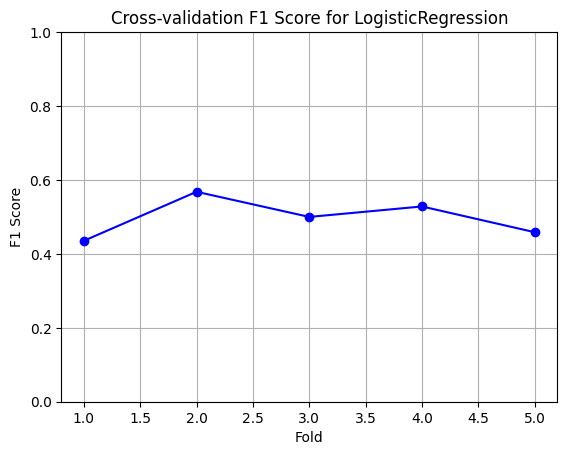

Mean F1 Score (CV): 0.4981
Accuracy: 0.4800
Precision (weighted): 0.4802
Recall (weighted): 0.4800
Recall (positive class): 0.5051
Confusion Matrix:
[[46 55]
 [49 50]]
--------------------------------------------------
Model: SVM


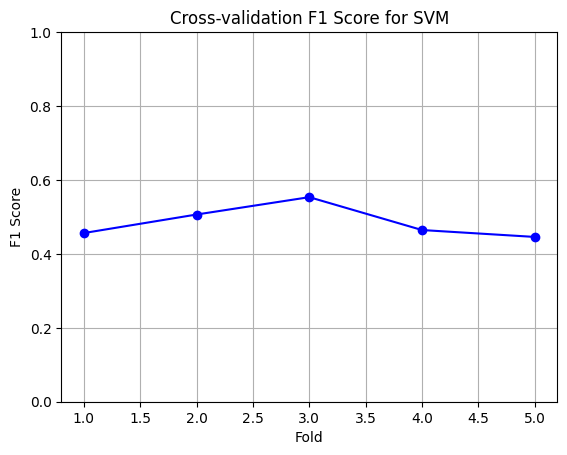

Mean F1 Score (CV): 0.4853
Accuracy: 0.4350
Precision (weighted): 0.4351
Recall (weighted): 0.4350
Recall (positive class): 0.4444
Confusion Matrix:
[[43 58]
 [55 44]]
--------------------------------------------------


In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'LogisticRegression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'SVM': SVC(probability=True, random_state=42)
}

# Huấn luyện và đánh giá models
for name, model in models.items():
    print(f"Model: {name}")

    # Cross-validation trên dữ liệu đã SMOTE và chuẩn hóa
    cv_scores = cross_val_score(model, X_train_resampled, y_train_resampled, cv=kf, scoring='f1')

    # Vẽ biểu đồ điểm F1 từng fold
    plt.figure()
    plt.plot(range(1, len(cv_scores) + 1), cv_scores, marker='o', linestyle='-', color='blue')
    plt.title(f'Cross-validation F1 Score for {name}')
    plt.xlabel('Fold')
    plt.ylabel('F1 Score')
    plt.ylim(0, 1)
    plt.grid(True)
    plt.show()

    print(f"Mean F1 Score (CV): {cv_scores.mean():.4f}")

    # Huấn luyện model trên toàn bộ dữ liệu train đã SMOTE và chuẩn hóa
    model.fit(X_train_resampled, y_train_resampled)

    X_test_imputed = X_test.copy()
    X_test_imputed[valid_num_cols] = imputer.transform(X_test[valid_num_cols])

    for col in all_nan_cols:
        X_test_imputed[col] = 0

    X_test_scaled = scaler.transform(X_test_imputed)

    # Bây giờ gọi predict sẽ không lỗi
    y_pred = model.predict(X_test_scaled)

    # Lưu model
    filename = f'/content/drive/My Drive/Project_DataMining/output/trainFirst_{name}.pkl'
    joblib.dump(model, filename)

    # Đánh giá kết quả trên tập test
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision (weighted): {precision_score(y_test, y_pred, average='weighted'):.4f}")
    print(f"Recall (weighted): {recall_score(y_test, y_pred, average='weighted'):.4f}")
    print(f"Recall (positive class): {recall_score(y_test, y_pred, pos_label=1):.4f}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("-" * 50)